## Simulate visibility

In [1]:
import os, sys
import numpy as np
from astropy.constants import c
from astropy import units as u
from collections import defaultdict
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from cmcrameri import cm

from astropy.io import fits
from astropy.wcs import WCS

from casatasks import listobs, mstransform, statwt, simobserve, tclean, exportfits, uvsub, immoments
from casatools import ms, table

from glint.beam import cleanbeam_from_header
import glint.lensing as ls
from glint.context import ImageContext
from glint.forward import forward_model_3D_image
from glint.plotstyle import set_my_plot_style
from params_kinematics import param_names, param_table

%matplotlib inline

In [2]:
set_my_plot_style()

## Simobserve

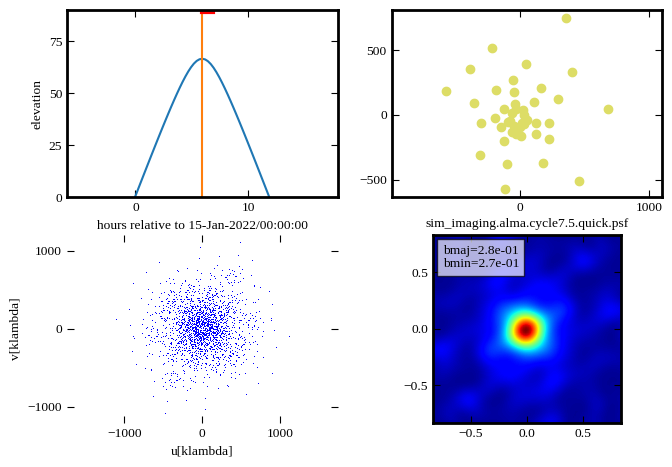

In [3]:
os.system('rm -rf sim_imaging/*')
simobserve(
    project            = 'sim_imaging',
    skymodel           = "mock_lensed_cube.fits", ###0埋めデータ/ノイズデータ？
    # inbright           = "1mJy/pixel", ###0で装置のノイズのみになるはず？-->なってそうだけど観測時間100倍にしてもノイズ8倍くらいしか減らないのはなぜ？？
    indirection        = "J2000 09:00:45.833000 +00.41.23.20000", ###directionとの違いは？-->多分skymodelの一部を疑似観測する場合に使う。これはskymodelの座標を定める(ヘッダーを上書きする)。center of GOODS-ALMA。
    incell             = "0.02arcsec", ###ヘッダーを上書きするはず。
    # incenter           = "270GHz", ###同じくskymodelのサブパラメータ
    # inwidth            = "50MHz",
    outframe           = 'LSRK', # デフォルトで "LSRK"、"BARY"もどっちも時間依存しない。特に理由はないけどデフォルトにしておく。
    setpointings       = True, ###If true (default), calculate a map of pointings and write ptgfile. If false, read pointings from ptgfile.
    integration        = "3600s", ###defaultでは10s。多分1scanの積分時間（チョッピング周期かな？）。ポインティングごとに細かく変えたい時はptgファイルで上書きできる。
    direction          = "J2000 09:00:45.833000 +00.41.23.20000", ###実際に観測するMosaic center
    # mapsize            = ["-280arcmin", "280arcmin"], ###空欄(default)だとskymodelに合わせる
    maptype            = "hexagonal", ###rasterもある
    pointingspacing    = "", ###空欄でALMAのdefaultに設定される(~0.51HPBW)
    obsmode		       = "int", ###interferometer mode
    antennalist        = './data/configuration_files/alma.cycle7.5.cfg' ,
    refdate            = "2022/1/15", ###Not critical unless concatting simulations
    hourangle          = "0h", ###「北中」する時(transitだと半分しかできない)
    totaltime          = "60s", # 72/4=18
    caldirection       = "",
    calflux            = "1Jy",
    thermalnoise       = "tsys-atm",
    user_pwv           = 0.1, ###かなり良い条件を仮定(default=0.5)
    t_ground           = 270.0, ###default=270
    seed               = 111,
    leakage            = 0.0, ###polarization leakage
    # graphics           = "none",
    verbose            = True,
    overwrite          = True
)

In [4]:
exportfits(imagename="./sim_imaging/sim_imaging.alma.cycle7.5.skymodel", fitsimage="./sim_imaging/sim_imaging.alma.cycle7.5.skymodel.fits", dropdeg=True, overwrite=True)

In [5]:
listobs('sim_imaging/sim_imaging.alma.cycle7.5.noisy.ms', listfile='sim_imaging/sim_imaging.alma.cycle7.5.noisy.listobs', overwrite=True)
!cat sim_imaging/sim_imaging.alma.cycle7.5.noisy.listobs

           MeasurementSet Name:  /lwk/atsujita/HATLASJ0900/glint/examples/sim_imaging/sim_imaging.alma.cycle7.5.noisy.ms      MS Version 2
   Observer: CASA simulator     Project: sim_imaging.alma.cycle7.5  
Observation: ALMA
Data records: 903       Total elapsed time = 3600 seconds
   Observed from   15-Jan-2022/05:55:20.4   to   15-Jan-2022/06:55:20.4 (UTC)

   ObservationID = 0         ArrayID = 0
  Date        Timerange (UTC)          Scan  FldId FieldName             nRows     SpwIds   Average Interval(s)    ScanIntent
  15-Jan-2022/05:55:20.4 - 06:55:20.4     1      0 sim_imaging.alma.cy*       903  [0]  [3.6e+03] [OBSERVE_TARGET#ON_SOURCE]
           (nRows = Total number of rows per scan) 
Fields: 1
  ID   Code Name                RA               Decl           Epoch   SrcId      nRows
  0    OBJ  sim_imaging.alma.cy*09:00:45.833000 +00.41.23.20000 J2000   0            903
Spectral Windows:  (1 unique spectral windows and 1 unique polarization setups)
  SpwID  Name   #Chans   

In [6]:
269729.235 + 45127.486*1e-3 * np.arange(12)

array([269729.235   , 269774.362486, 269819.489972, 269864.617458,
       269909.744944, 269954.87243 , 269999.999916, 270045.127402,
       270090.254888, 270135.382374, 270180.50986 , 270225.637346])

In [7]:
exportfits('./sim_imaging/sim_imaging.alma.cycle7.5.skymodel', 
           './sim_imaging/sim_imaging.alma.cycle7.5.skymodel.fits', 
           dropdeg=True, overwrite=True)

## mstransform

In [8]:
# outputvis = "./sim_imaging/sim_imaging.alma.cycle7.5.ms.tbin"
outputvis = "./sim_imaging/sim_imaging.alma.cycle7.5.noisy.ms.tbin"

In [9]:
mstransform(
    vis="./sim_imaging/sim_imaging.alma.cycle7.5.noisy.ms",
    outputvis=outputvis,
    outframe='LSRK', # 指定しておかないと端のチャンネルが空になったりするので注意
    maxuvwdistance=12.0, timespan='scan', timeaverage=True, timebin='10000000s',
    keepflags=True
)

_ = listobs(vis=outputvis, listfile=f"{outputvis}.listobs", overwrite=True)  # to check the spw info
!cat "{outputvis}.listobs"

2026-05-05 05:02:25	WARN	MSTransformManager::parseTimeAvgParams	Operating with ALMA data, automatically adding state to timespan 
2026-05-05 05:02:25	WARN	MSTransformManager::parseTimeAvgParams+	In order to remove sub-scan boundaries which limit time average to 30s 


           MeasurementSet Name:  /lwk/atsujita/HATLASJ0900/glint/examples/sim_imaging/sim_imaging.alma.cycle7.5.noisy.ms.tbin      MS Version 2
   Observer: CASA simulator     Project: sim_imaging.alma.cycle7.5  
Observation: ALMA
Data records: 903       Total elapsed time = 3600 seconds
   Observed from   15-Jan-2022/05:55:20.4   to   15-Jan-2022/06:55:20.4 (UTC)

   ObservationID = 0         ArrayID = 0
  Date        Timerange (UTC)          Scan  FldId FieldName             nRows     SpwIds   Average Interval(s)    ScanIntent
  15-Jan-2022/05:55:20.4 - 06:55:20.4     1      0 sim_imaging.alma.cy*       903  [0]  [3.6e+03] [OBSERVE_TARGET#ON_SOURCE]
           (nRows = Total number of rows per scan) 
Fields: 1
  ID   Code Name                RA               Decl           Epoch   SrcId      nRows
  0    OBJ  sim_imaging.alma.cy*09:00:45.833000 +00.41.23.20000 J2000   0            903
Spectral Windows:  (1 unique spectral windows and 1 unique polarization setups)
  SpwID  Name   #Cha

In [10]:
REST_FREQ_CII = 1900.5369 * u.GHz
z = 6.024
OBS_FREQ_CII = REST_FREQ_CII / (1 + z)
print(f"Observed [CII] frequency: {OBS_FREQ_CII:.4f}")

os.system("rm -r ./sim_imaging/casa_dirty*")
tclean(
    vis=outputvis,
    imagename="./sim_imaging/casa_dirty",
    imsize=200,
    cell="0.02arcsec",
    weighting="natural",
    niter=0,
    outframe='LSRK', # 意外と大事
    stokes="I",
    specmode="cube",
    # interpolation="nearest", # これがデフォルトのlinearだと端のチャンネルが空になるが、nearestはよくない
    interactive=False,
    restfreq=f"{OBS_FREQ_CII.to(u.GHz).value}GHz",
    verbose=True,
)

exportfits(imagename='./sim_imaging/casa_dirty.image', fitsimage='./sim_imaging/casa_dirty.image.fits', dropdeg=True, overwrite=True)
exportfits(imagename='./sim_imaging/casa_dirty.psf', fitsimage='./sim_imaging/casa_dirty.psf.fits', dropdeg=True, overwrite=True)
# exportfits(imagename='./sim_imaging/sim_imaging.alma.cycle7.8.skymodel', fitsimage='./sim_imaging/casa_dirty.skymodel.fits', overwrite=True)

Observed [CII] frequency: 270.5776 GHz


rm: cannot remove './sim_imaging/casa_dirty*': No such file or directory


2026-05-05 05:02:28	WARN	task_tclean::SIImageStore::restore (file /source/casa6/casatools/src/code/synthesis/ImagerObjects/SIImageStore.cc, line 2284)	Restoring with an empty model image. Only residuals will be processed to form the output restored image.


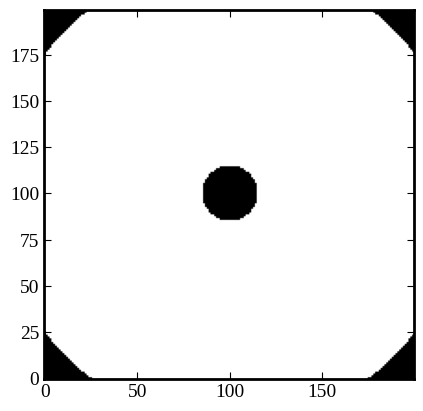

Number of pixels in the mask: 38166


2026-05-05 05:02:29	WARN	importfits::::casa	This image has no beam or angular resolution provided, so you will not receive warnings from
2026-05-05 05:02:29	WARN	importfits::::casa+	tasks such as imregrid if your image pixels do not sample the the angular resolution well.
2026-05-05 05:02:29	WARN	importfits::::casa+	(This only affects warnings, not any functionality).
2026-05-05 05:02:29	WARN	importfits::::casa+	Providing a beam and brightness units in an image can also be useful for flux calculations.
2026-05-05 05:02:29	WARN	importfits::::casa+	If you wish to add a beam or brightness units to your image, please use
2026-05-05 05:02:29	WARN	importfits::::casa+	the "beam" parameter or ia.setrestoringbeam() and ia.setbrightnessunit()


In [11]:
# mask

d, h = fits.getdata('./sim_imaging/casa_dirty.image.fits', header=True)
# 固定マスクを使う場合
# 円環マスク
maskdata = np.zeros(d.shape[1:]).astype(bool)
r_inner = 0.3 # arcsec
r_outer = 2.5 # arcsec
y, x = np.indices(d.shape[1:])
x_center = d.shape[2] / 2
y_center = d.shape[1] / 2
r = np.sqrt((x - x_center)**2 + (y - y_center)**2) * h["CDELT2"] * 3600
maskdata[(r >= r_inner) & (r <= r_outer)] = True
plt.imshow(maskdata, origin='lower', cmap='gray')
plt.show()

Npix = np.nansum(maskdata)
print(f"Number of pixels in the mask: {Npix}")

# save mask
fits.writeto('./sim_imaging/mask.fits', maskdata.astype(np.float32), overwrite=True)

from casatasks import importfits

# fits -> casa image
importfits(fitsimage='./sim_imaging/mask.fits',
           imagename='./sim_imaging/mask.image',
           overwrite=True)

(14, 200, 200)
RMS noise: 0.0009229189017787576 Jy/beam


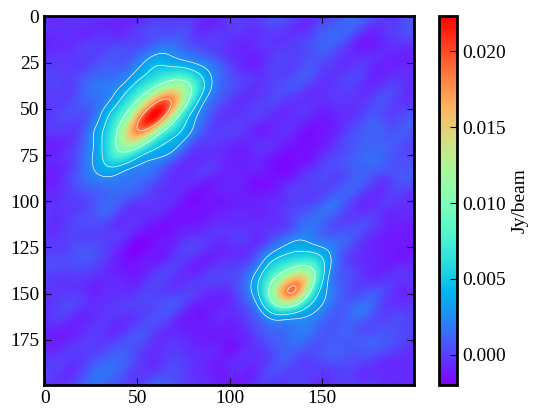

In [12]:
casa_dirty_image = fits.getdata('./sim_imaging/casa_dirty.image.fits')
print(casa_dirty_image.shape)

# rms
from astropy.stats import sigma_clipped_stats, mad_std
# rms = sigma_clipped_stats(casa_dirty_image, sigma=3.0, maxiters=5)[2]
rms = mad_std(casa_dirty_image, ignore_nan=True)
print(f"RMS noise: {rms} Jy/beam")

i = 3
plt.imshow(casa_dirty_image[i], cmap='rainbow')
plt.colorbar(label='Jy/beam')
plt.contour(casa_dirty_image[i]/rms, levels=[3,5,10,20], colors='white', linewidths=0.5)
# plt.contour(maskdata, levels=[0.5], colors='red', linewidths=1.0)
# plt.xlim(400, 600)
# plt.ylim(600, 400)
plt.show()

In [13]:
np.max(casa_dirty_image[i])

np.float32(0.02235222)

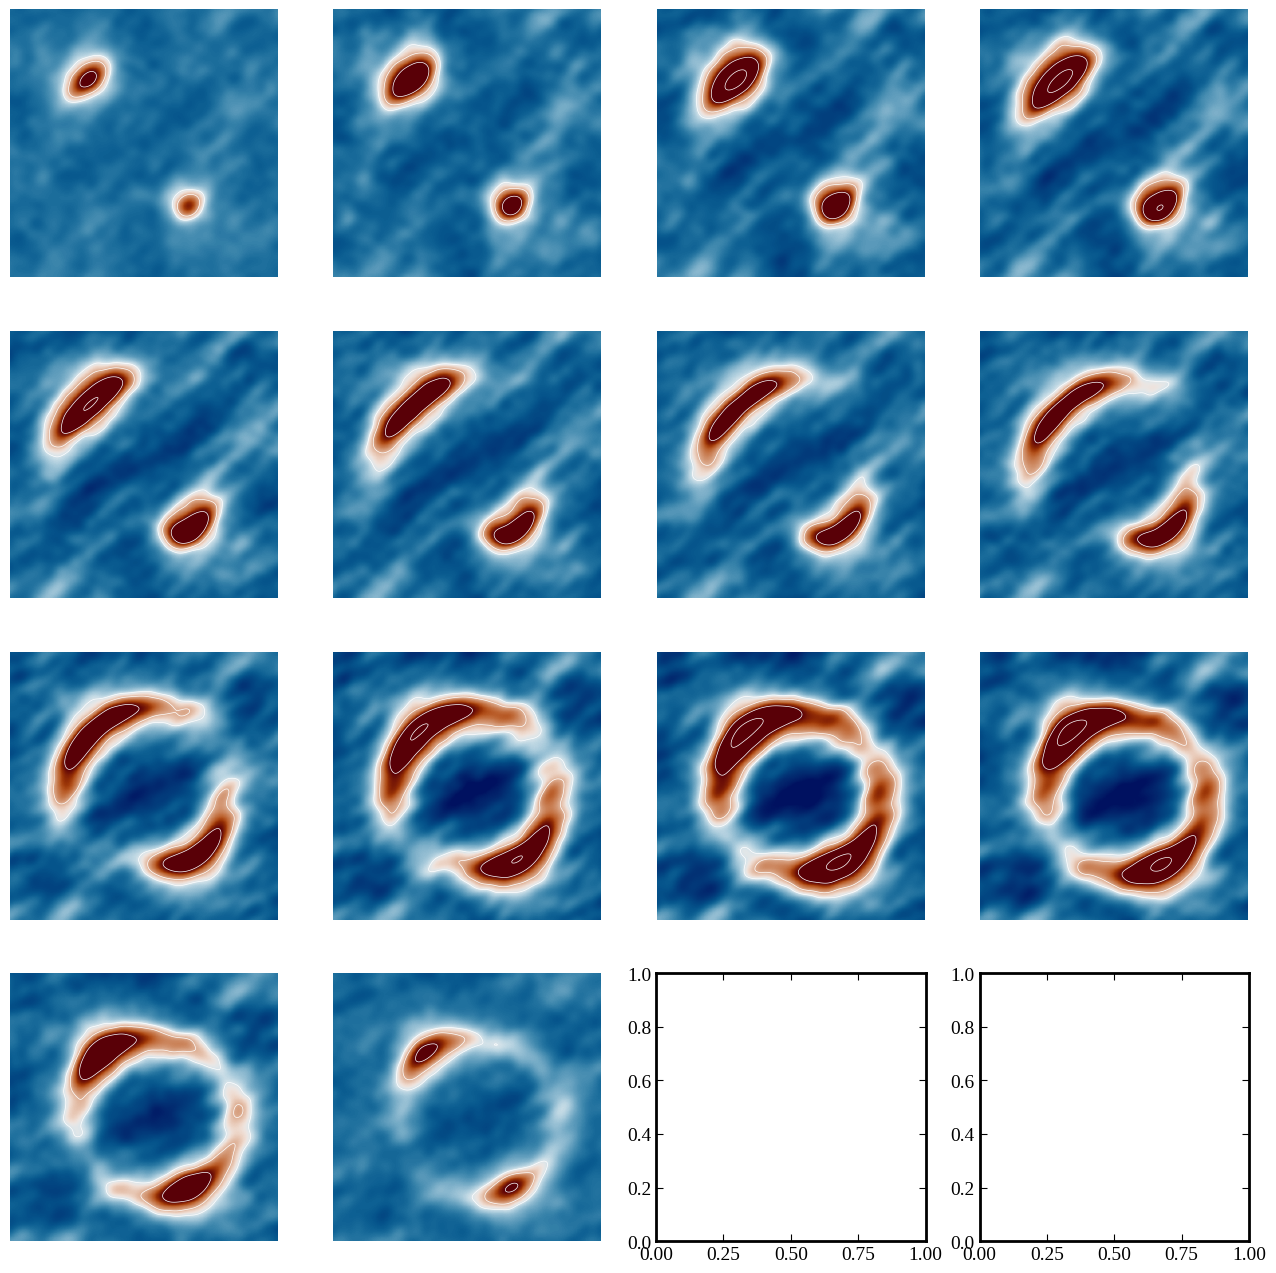

In [14]:
# 全チャンネルを並べて表示
nchan = casa_dirty_image.shape[0]
nrow = int(np.ceil(nchan / 4))
fig, axes = plt.subplots(nrow, 4, figsize=(16, 4*nrow))
for i in range(nchan):  
    ax = axes.flat[i]
    im = ax.imshow(casa_dirty_image[i], cmap=cm.vik, vmin=-3*rms, vmax=10*rms)
    ax.contour(casa_dirty_image[i]/rms, levels=[3,5,10,20], colors='white', linewidths=0.5)
    # ax.set_title(f'Channel {i}')
    ax.axis('off')
plt.show()

## tclean

In [15]:
# ==========
# 0) どのMSでやるか（あなたのmstransform出力を使う）
# ==========
vis0 = outputvis   # "./sim_imaging/sim_imaging.alma.cycle7.5.noisy.ms.tbin"

# ==========
# 1) MSにどの列があるか確認（DATA / CORRECTED_DATA / MODEL_DATA など）
# ==========
tb = table()
tb.open(vis0)
print("MAIN columns:", tb.colnames())
tb.close()

# MODEL列の有無を確認（MODEL_DATAはMAINにある）
has_model = False
tb.open(vis0)
has_model = "MODEL_DATA" in tb.colnames()
tb.close()
print("Has MODEL_DATA:", has_model)

# Corrected_DATA列の有無を確認（Corrected_DATAはMAINにある）
has_corrected = False
tb.open(vis0)
has_corrected = "CORRECTED_DATA" in tb.colnames()
tb.close()
print("Has CORRECTED_DATA:", has_corrected)

MAIN columns: ['UVW', 'FLAG', 'FLAG_CATEGORY', 'WEIGHT', 'SIGMA', 'ANTENNA1', 'ANTENNA2', 'ARRAY_ID', 'DATA_DESC_ID', 'EXPOSURE', 'FEED1', 'FEED2', 'FIELD_ID', 'FLAG_ROW', 'INTERVAL', 'OBSERVATION_ID', 'PROCESSOR_ID', 'SCAN_NUMBER', 'STATE_ID', 'TIME', 'TIME_CENTROID', 'DATA']
Has MODEL_DATA: False
Has CORRECTED_DATA: False


In [16]:
# ==========
# 2) まずモデルを作って MS の MODEL_DATA に書き込む
# ==========
os.system("rm -r ./sim_imaging/casa_clean*")
tclean(
    vis=outputvis,
    imagename="./sim_imaging/casa_clean",
    imsize=200,
    cell="0.02arcsec",
    weighting="natural",
    niter=1000000,
    stokes="I",
    specmode="cube",
    outframe="LSRK",
    deconvolver="hogbom",
    restoringbeam="common",
    interactive=False,
    nsigma=2,
    usemask="user",
    mask='./sim_imaging/mask.image',
    savemodel="modelcolumn",
    restfreq=f"{OBS_FREQ_CII.to(u.GHz).value}GHz"
)


# MODEL_DATAが本当に入ったか軽く確認
tb.open(vis0)
print("MODEL_DATA now exists:", "MODEL_DATA" in tb.colnames())
tb.close()

exportfits(imagename='./sim_imaging/casa_clean.image', fitsimage='./sim_imaging/casa_clean.image.fits', dropdeg=True, overwrite=True)

rm: cannot remove './sim_imaging/casa_clean*': No such file or directory


MODEL_DATA now exists: True


(14, 200, 200)


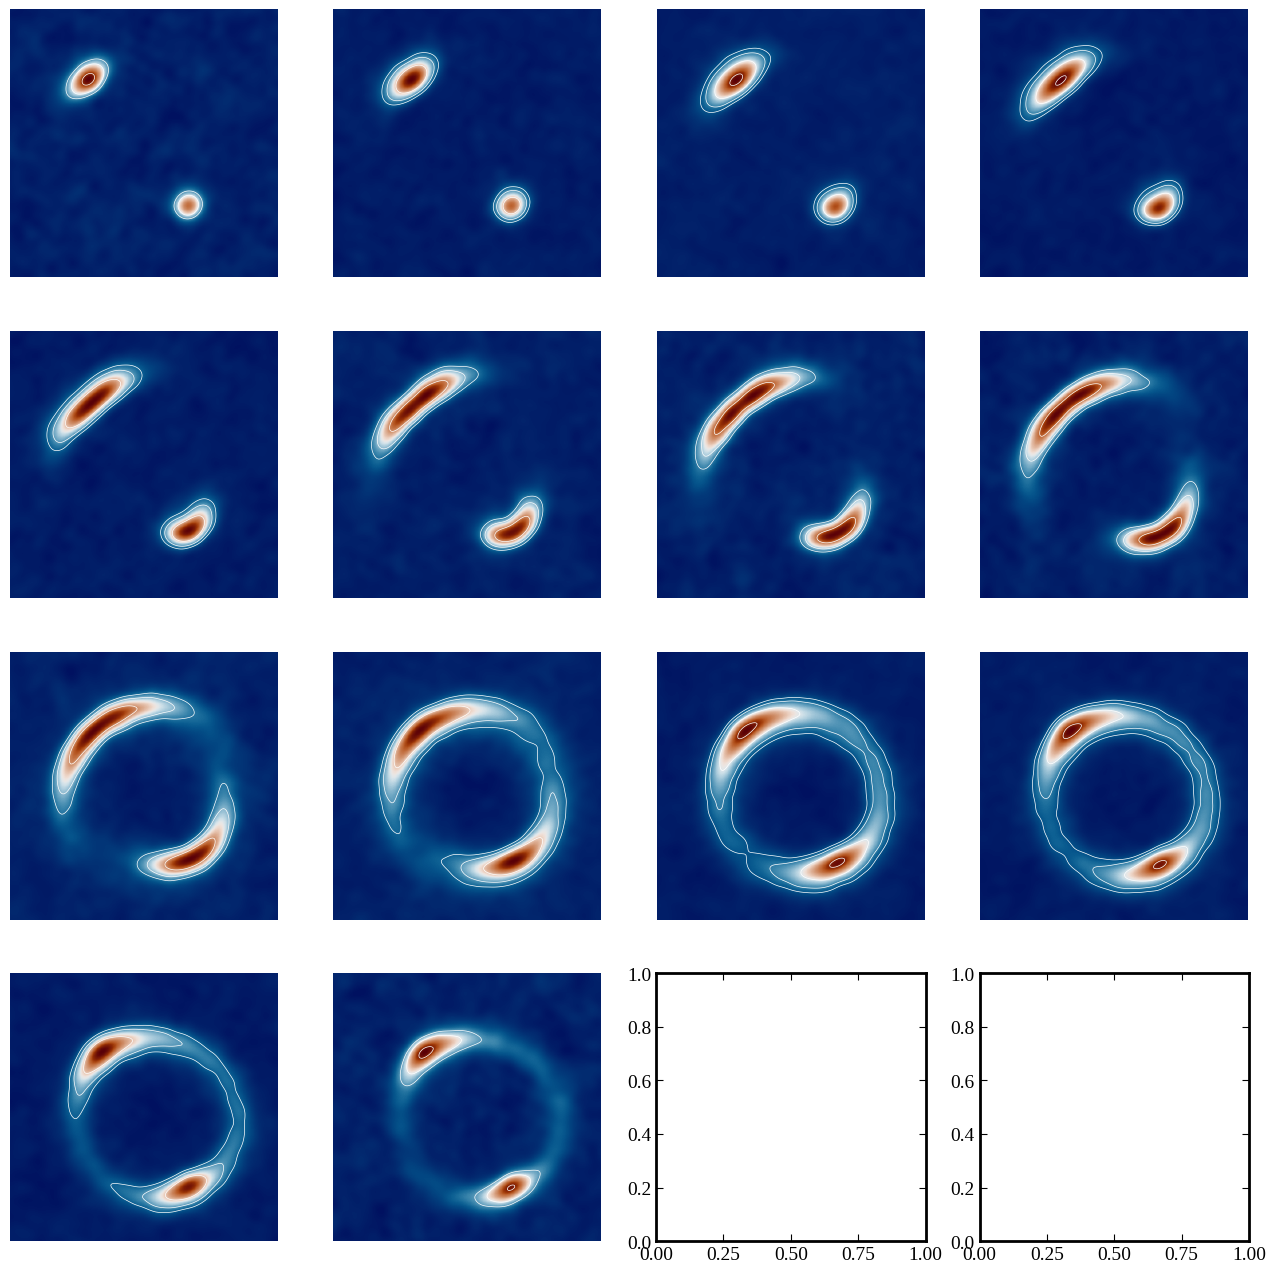

In [17]:
# 全チャンネルを並べて表示

casa_clean_image = fits.getdata('./sim_imaging/casa_clean.image.fits')
print(casa_clean_image.shape)

nchan = casa_clean_image.shape[0]
nrow = int(np.ceil(nchan / 4))
fig, axes = plt.subplots(nrow, 4, figsize=(16, 4*nrow))
for i in range(nchan):  
    ax = axes.flat[i]
    im = ax.imshow(casa_clean_image[i], cmap=cm.vik)
    ax.contour(casa_clean_image[i]/rms, levels=[3,5,10,20], colors='white', linewidths=0.5)
    # ax.set_title(f'Channel {i}')
    ax.axis('off')
    # ax.set_xlim(300, 700)
    # ax.set_ylim(300, 700)
plt.show()

(14, 200, 200)


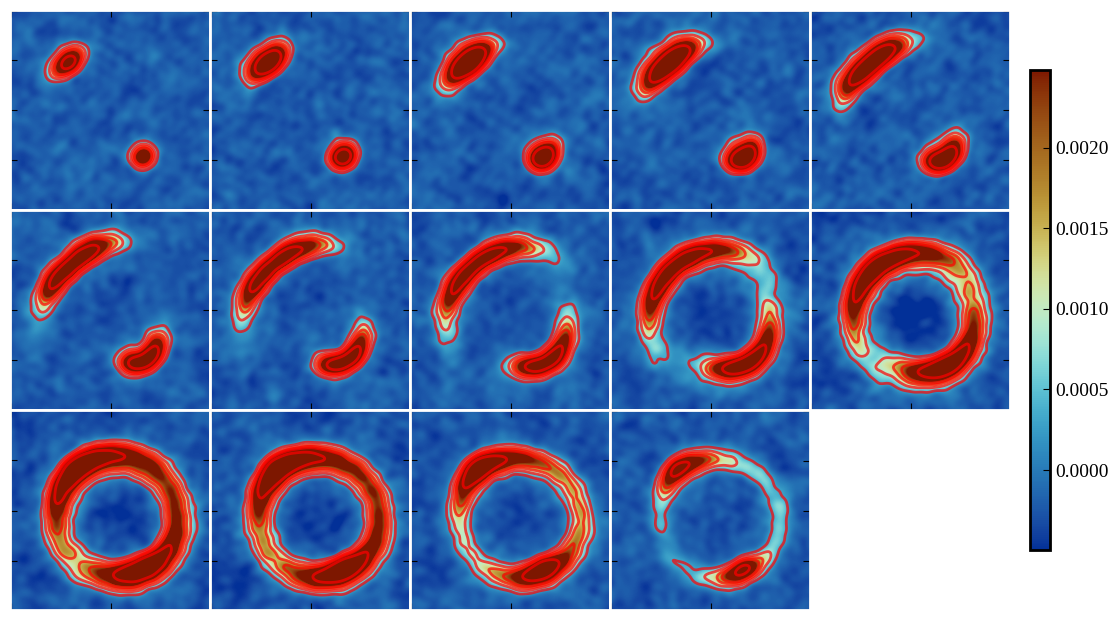

In [18]:
# 全チャンネルを並べて表示

casa_clean_image = fits.getdata('./sim_imaging/casa_clean.image.fits')
print(casa_clean_image.shape)

n_cols = 5
n_chan = casa_clean_image.shape[0]
n_rows = int(np.ceil(n_chan / n_cols))

start = 0
rms = mad_std(casa_clean_image, ignore_nan=True)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(2*n_cols, 2*n_rows))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0.0, hspace=0.0)
for i in range(n_rows * n_cols):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col]
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.spines['bottom'].set_color("white")
    ax.spines['top'].set_color("white")
    ax.spines['right'].set_color("white")
    ax.spines['left'].set_color("white")

    # ax.set_xlim(400, 600)
    # ax.set_ylim(400, 600)
    if i < n_chan:
        ax.imshow(casa_clean_image[start+i], cmap=cm.roma_r, vmin=-2*rms, vmax=20*rms)
        ax.contour(casa_clean_image[start+i]/rms, levels=[4, 8, 12, 16, 32], colors='red', alpha=0.7, linewidths=2)
        
        # ax.annotate(f"{int(vel_start+dv*i)}km/s", xy=(0.25, 0.87), xytext=(0, 0), color='white', xycoords='axes fraction', textcoords='offset points',weight='bold', ha='center', va='baseline', fontsize=25)
        # ellipse = Ellipse(xy=(0,0), width=BMAJ, height=BMIN, angle=BPA+90.,edgecolor='none', fc='white', lw=0.5)  # must be define any time
        # ax.add_patch(ellipse)
    
    # if i==0:
    #     size = 1/pix
    #     fontprops = fm.FontProperties(size=40)
    #     scalebar = AnchoredSizeBar(ax.transData,
    #                             size, r'1$^{\prime\prime}$', 'lower right',
    #                             pad=0.3,
    #                             sep=5,
    #                             color='white',
    #                             frameon=False,
    #                             size_vertical=2,
    #                             fontproperties=fontprops)
    #     ax.add_artist(scalebar)
    
    if i >= n_chan:
        ax.axis('off')

# 全体のカラーバー
cbar_ax = fig.add_axes([1.02, 0.1, 0.02, 0.8])  # [left, bottom, width, height]
norm = plt.Normalize(vmin=-2*rms, vmax=10*rms)
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cm.roma_r), cax=cbar_ax)

plt.show()

In [19]:
# ==========
# 3) uvsubで DATA - MODEL を作り、CORRECTED_DATA に残差が入る
# （statwtで計算できるから不要っぽい）
# ==========
vis0 = outputvis   # "./sim_imaging/sim_imaging.alma.cycle7.5.noisy.ms.tbin"
uvsub(vis=vis0, reverse=False)

# CORRECTED_DATA の有無を確認
tb = table()
tb.open(vis0)
cols = tb.colnames()
tb.close()
print("Has CORRECTED_DATA:", "CORRECTED_DATA" in cols)

Has CORRECTED_DATA: True


In [20]:
# ==========
# 4) statwt：残差からノイズ推定
#    - CORRECTED_DATA があるなら datacolumn="CORRECTED_DATA"（= DATA - MODEL）
#    - 無いなら datacolumn="residual_data"（= DATA - MODEL）
#    ※preview=Trueでまず確認すると安全
# ==========
datacol = "CORRECTED_DATA" if ("CORRECTED_DATA" in cols) else "residual_data"
print("Using datacolumn =", datacol)

statwt(
    vis=vis0,
    datacolumn=datacol,
    combine="scan",     # 例：scan内でまとめて分散推定（必要なら "scan,field" 等）
    timebin="300s",        # 1 integration 単位（または "60s" など）
    chanbin="spw",      
    minsamp=2,      # 最低限必要なサンプル数（これ以下ならスキップ）
    preview=False,
    flagbackup=True
)

Using datacolumn = CORRECTED_DATA


{'mean': 36303.539651357496, 'variance': 152902671.14631775}

In [21]:
tb = table()
tb.open(vis0)
w = tb.getcol("WEIGHT")   # shape: (ncorr, nrow) が多い
s = tb.getcol("SIGMA")
tb.close()

print("WEIGHT min/med/max:", np.nanmin(w), np.nanmedian(w), np.nanmax(w))
print("SIGMA  min/med/max:", np.nanmin(s), np.nanmedian(s), np.nanmax(s))

# WEIGHTからsigmaを再計算して比較
sig_from_w = 1.0/np.sqrt(w)
print("sigma(from WEIGHT) min/med/max:", np.nanmin(sig_from_w), np.nanmedian(sig_from_w), np.nanmax(sig_from_w))

WEIGHT min/med/max: 5068.240234375 34569.033203125 102645.15625
SIGMA  min/med/max: 1.0 1.0 1.0
sigma(from WEIGHT) min/med/max: 0.0031212659159969187 0.0053784408144717764 0.014046606097751893


In [22]:
#########################
# {'mean': 45.186852242859324, 'variance': 4.708463560305805}  # chanbin=spw, tbin=300s
#########################

# statwtはsigmaを更新してくれてないので注意！


### 軽くテスト

Shape of CORRECTED_DATA: (2, 14, 903), WEIGHT: (2, 903), FLAG: (2, 14, 903)
z mean/std: -0.02163437709619377 1.0688208800194974
frac(|z|>3): 0.00492406264831514
frac(|z|>5): 0.0


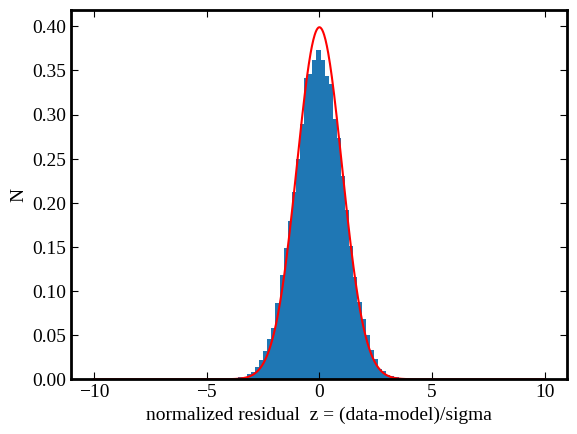

In [23]:
# まずσが正規分布になっているか確認

tb = table()
tb.open(vis0)
cols = tb.colnames()
d = tb.getcol("DATA")           # shape (ncorr, nchan, nrow)
r = tb.getcol("CORRECTED_DATA") # uvsub後の残差はCORRECTED_DATAに入っている
w = tb.getcol("WEIGHT")
f = tb.getcol("FLAG")
uvw = tb.getcol("UVW")      # shape (3, nrow) [m]
tb.close()

tb.open(vis0 + "/SPECTRAL_WINDOW")
chan_freq = tb.getcol("CHAN_FREQ")[:,0]  # Hz
tb.close()

s = 1.0/np.sqrt(w)
print(f"Shape of CORRECTED_DATA: {r.shape}, WEIGHT: {w.shape}, FLAG: {f.shape}")

# broadcast
s = s[:, None, :]
s = np.broadcast_to(s, r.shape)

# フラグを除外
good = ~f
z_re = np.real(r)[good] / s[good]
z_im = np.imag(r)[good] / s[good]

z = np.concatenate([z_re, z_im])

print("z mean/std:", np.mean(z), np.std(z))
print("frac(|z|>3):", np.mean(np.abs(z) > 3))
print("frac(|z|>5):", np.mean(np.abs(z) > 5))

plt.figure()
plt.hist(z, bins=50, density=True)
plt.xlabel("normalized residual  z = (data-model)/sigma")
plt.ylabel("N")

# ガウシアン分布も重ねてみる
from scipy.stats import norm
x = np.linspace(-10, 10, 1000)
pdf = norm.pdf(x, loc=0, scale=1)
plt.plot(x, pdf, color='red', label='Gaussian PDF')

plt.show()

In [24]:
tb.open(vis0 + "/SPECTRAL_WINDOW")
chan_freq = tb.getcol("CHAN_FREQ")  # Hz
tb.close()

chan_freq.shape

(14, 1)

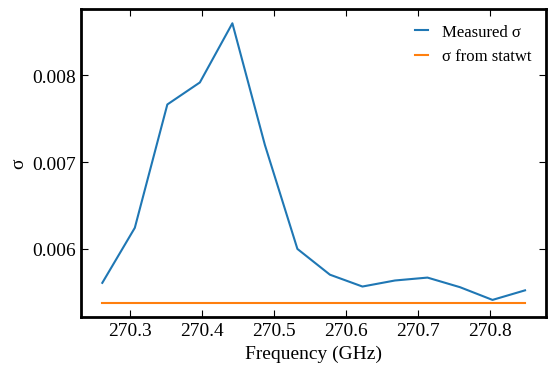

In [25]:
# チャンネルごとのノイズ・外れ値を確認

# ---- チャネル毎ノイズ比較 ----
s_data = []
s_statwt = []

for ch in range(r.shape[1]):
    good = ~f[:,ch,:]
    rr = r[:,ch,:][good]
    ss = s[:,ch,:][good]

    s_data.append(np.std(np.real(rr)))
    s_statwt.append(np.median(ss))

s_data = np.array(s_data)
s_statwt = np.array(s_statwt)

# ---- プロット ----
plt.figure(figsize=(6,4))
plt.plot(chan_freq/1e9, s_data, label="Measured σ")
plt.plot(chan_freq/1e9, s_statwt, label="σ from statwt")
plt.xlabel("Frequency (GHz)")
plt.ylabel("σ")
plt.legend()
plt.show()

uvdist [m] min/med/max: 14.713606648664003 346.01507820859916 1323.2167267261575
z_row mean/std: -0.04452793687751285 0.4431230649980352


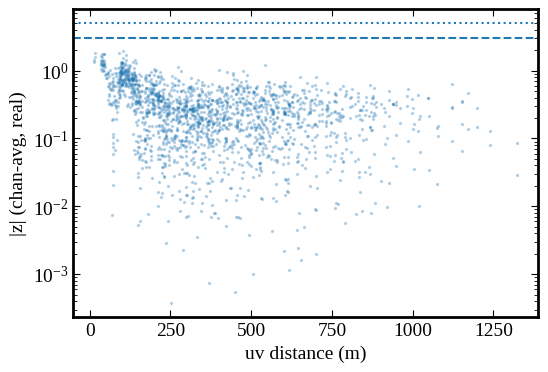

In [26]:
uvdist = np.sqrt(uvw[0]**2 + uvw[1]**2)  # [m], shape (nrow,)
print("uvdist [m] min/med/max:", np.min(uvdist), np.median(uvdist), np.max(uvdist))

ncorr, nchan, nrow = r.shape

# フラグをNaN化してchan平均 → (ncorr, nrow)
r_re_row = np.nanmean(np.where(f, np.nan, np.real(r)), axis=1)
s_row    = np.nanmedian(np.where(f, np.nan, s), axis=1)  # chan方向はmedianが安全

# corrもまとめて 1本に
r_re_row_1d = r_re_row.ravel()          # (ncorr*nrow,)
s_row_1d    = s_row.ravel()             # (ncorr*nrow,)
uv_rep      = np.tile(uvdist, ncorr)    # (ncorr*nrow,)

m = np.isfinite(r_re_row_1d) & np.isfinite(s_row_1d)
r_re_row_1d = r_re_row_1d[m]
s_row_1d    = s_row_1d[m]
uv_rep      = uv_rep[m]

# “rowごとの正規化残差”
z_row = r_re_row_1d / s_row_1d
print("z_row mean/std:", np.mean(z_row), np.std(z_row))

plt.figure(figsize=(6,4))
plt.scatter(uv_rep, np.abs(z_row), s=2, alpha=0.25)
plt.axhline(3, ls="--")
plt.axhline(5, ls=":")
plt.yscale("log")
plt.xlabel("uv distance (m)")
plt.ylabel("|z| (chan-avg, real)")
plt.show()

## signal-to-noise map

SNR row (per corr) median: [3.69492892 3.65419173]


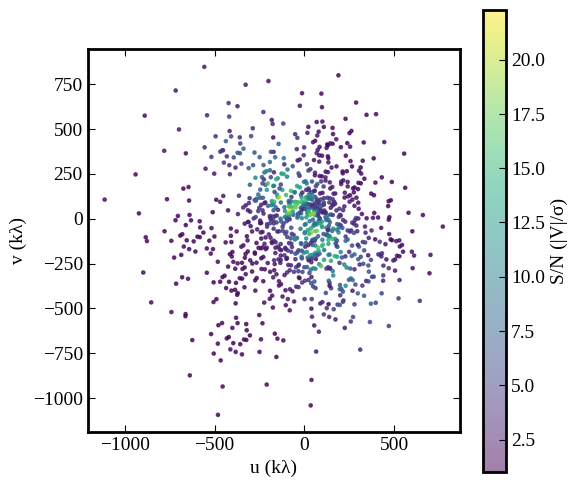

In [27]:
from astropy.constants import c

# vis0 = outputvis   # "./sim_imaging/sim_imaging.alma.cycle7.5.noisy.ms.tbin"
vis = vis0  # あなたのMS


# フラグをNaN化してチャネル平均（各rowに1値）
Vabs = np.abs(d)
Vabs = np.where(f, np.nan, Vabs)
sig  = np.where(f, np.nan, s)

amp_row   = np.nanmean(Vabs, axis=1)        # (ncorr, nrow)
sig_row   = np.nanmedian(sig, axis=1)       # (ncorr, nrow)  medianが頑丈
snr_row   = amp_row / sig_row               # (ncorr, nrow)

print("SNR row (per corr) median:", np.nanmedian(snr_row, axis=1))

nu = np.median(chan_freq)  # Hz
lam = (c.value) / nu       # m

u_kl = uvw[0] / lam / 1e3
v_kl = uvw[1] / lam / 1e3

snr_1d = snr_row.ravel()                 # (ncorr*nrow,)
u_1d   = np.tile(u_kl, snr_row.shape[0])
v_1d   = np.tile(v_kl, snr_row.shape[0])

m = np.isfinite(snr_1d)
snr_1d = snr_1d[m]
u_1d   = u_1d[m]
v_1d   = v_1d[m]

plt.figure(figsize=(6,6))
sc = plt.scatter(u_1d, v_1d, c=snr_1d, s=5, alpha=0.5)
plt.xlabel("u (kλ)")
plt.ylabel("v (kλ)")
plt.gca().set_aspect("equal", "box")
plt.colorbar(sc, label="S/N (|V|/σ)")
plt.show()

In [28]:
good = ~f
rr = d[good]
ss = s[good]

chi2_complex = np.sum( (np.real(rr)/ss)**2 + (np.imag(rr)/ss)**2 )
Ndof = 2 * rr.size   # ReとImで2自由度（厳密にはflagで変わるがOK）

print("chi2_complex:", chi2_complex)
print("chi2/dof:", chi2_complex / Ndof)

chi2_complex: 1201440.7585065153
chi2/dof: 23.758913908133906


In [29]:
good = ~f
rr = r[good]
ss = s[good]

chi2_complex = np.sum( (np.real(rr)/ss)**2 + (np.imag(rr)/ss)**2 )
Ndof = 2 * rr.size   # ReとImで2自由度（厳密にはflagで変わるがOK）

print("chi2_complex:", chi2_complex)
print("chi2/dof:", chi2_complex / Ndof)

print("rr real std:", np.std(np.real(rr)))
print("rr imag std:", np.std(np.imag(rr)))
print("ss median:", np.median(ss))
print("ss p16/p50/p84:", np.percentile(ss, [16,50,84]))
print("min/max ss:", np.min(ss), np.max(ss))

chi2_complex: 57791.44258796763
chi2/dof: 1.142846119837993
rr real std: 0.00639651136699601
rr imag std: 0.00568002518377619
ss median: 0.0053784408144717764
ss p16/p50/p84: [0.00459508 0.00537844 0.00631398]
min/max ss: 0.0031212659159969187 0.014046606097751893


## テスト完了したので、あとは保存する

汎用的にしておく

In [30]:
## uv dataをbinにまとめる
    
def getdata(ms):
    """
    注意：配列が同じshapeでないと全部取れない。channel数がspwによって違う場合は正しくない。
    そういう場合は getvarcol を使うこと。ここではどうせ全部平均するので問題ないが。
    uは東向き正になっている模様：https://casa.nrao.edu/Memos/CoordConvention.pdf 
    """
    tb = table()
    tb.open(ms)
    obsid      = np.squeeze(tb.getcol("OBSERVATION_ID")) # EB
    uvw        = np.squeeze(tb.getcol("UVW")) # uは東向き正になっているので注意、あとでu*l計算するときに符号反転させる
    ant1       = np.squeeze(tb.getcol("ANTENNA1"))
    ant2       = np.squeeze(tb.getcol("ANTENNA2"))
    data_pol   = np.squeeze(tb.getcol("DATA"))
    corrected_pol = np.squeeze(tb.getcol("CORRECTED_DATA"))
    sigma_pol  = np.squeeze(tb.getcol("SIGMA"))
    weight_pol = np.squeeze(tb.getcol("WEIGHT"))
    data_id    = np.squeeze(tb.getcol("DATA_DESC_ID")) # SPW
    time       = np.squeeze(tb.getcol("TIME"))
    scan       = np.squeeze(tb.getcol("SCAN_NUMBER"))
    flag       = np.squeeze(tb.getcol("FLAG"))
    tb.close()

    # phase center
    tb.open(ms + "/FIELD")
    phase_dir = np.squeeze(tb.getcol("PHASE_DIR"))
    tb.close()
    phase_dir = np.rad2deg(phase_dir)  # [rad] -> [deg]
    
    # print shapes
    print(f"Shape of obsid: {obsid.shape}")
    print(f"Shape of uvw: {uvw.shape}")
    print(f"Shape of ant1: {ant1.shape}")
    print(f"Shape of ant2: {ant2.shape}")
    print(f"Shape of data: {data_pol.shape}")
    print(f"Shape of sigma: {sigma_pol.shape}")
    print(f"Shape of weight: {weight_pol.shape}")
    print(f"Shape of data_id: {data_id.shape}")
    print(f"Shape of time: {time.shape}")
    print(f"Shape of scan: {scan.shape}")
    print(f"Shape of flag: {flag.shape}")
    print(f"phase center (deg): {phase_dir}")

    return obsid, uvw, ant1, ant2, data_pol, corrected_pol, sigma_pol, weight_pol, data_id, time, scan, flag, phase_dir

In [31]:
# uvsubは終わっていて、CORRECTED_DATAに残差が入っている
# かつstatwtでWEIGHTが更新されていることを想定

vis0 = outputvis   # "./sim_imaging/sim_imaging.alma.cycle7.5.noisy.ms.tbin"
obsid, uvw, ant1, ant2, data_pol, corrected_pol, sigma_pol, weight_pol, data_id, time, scan, flag, phase_dir = getdata(vis0)

print(f"Number of flagged data points: {np.sum(flag)} / {flag.size}")

Shape of obsid: (903,)
Shape of uvw: (3, 903)
Shape of ant1: (903,)
Shape of ant2: (903,)
Shape of data: (2, 14, 903)
Shape of sigma: (2, 903)
Shape of weight: (2, 903)
Shape of data_id: (903,)
Shape of time: (903,)
Shape of scan: (903,)
Shape of flag: (2, 14, 903)
phase center (deg): [135.19097083   0.68977778]
Number of flagged data points: 0 / 25284


In [32]:
903

903

In [33]:
# 周波数
# Get the frequencies assoc. with each spw, since uvw coordinates are in m, not wavelengths
spw = "0"
tb = table()
tb.open(vis0+'/SPECTRAL_WINDOW')
t1 = tb.selectrows([int(s) for s in spw.split(',')])
freqs = np.squeeze(t1.getcol('CHAN_FREQ')) # 複数のspwがある場合、揃えた上で最初のspwの周波数を使う
t1.close(); tb.close()

print("Frequencies for each SPW (Hz):", freqs)


# Get the primary beam size
diam = 12.0  # ALMA antenna diameter in m
PBfwhm = (1.13 * (c / np.mean(freqs*u.Hz)) / (diam*u.m) * (3600*180/np.pi)).to("")

print(f"Primary beam FWHM (arcsec): {PBfwhm:.3f}")


v_kms = -( (freqs - OBS_FREQ_CII.to(u.Hz).value) / OBS_FREQ_CII.to(u.Hz).value * c.to(u.km/u.s).value )  # (nchan,)
v_kms = np.arange(-300, 351, 50) # 後でmock cleantするときに箸が切れないように端に一つづつおおめにとる
print(v_kms)

# # 
# is_cont_ch = (np.abs(v_kms) >= 350.0)  # (nchan,)
# print("line-free channels:", np.where(is_cont_ch)[0])

Frequencies for each SPW (Hz): [2.70848342e+11 2.70803214e+11 2.70758087e+11 2.70712959e+11
 2.70667832e+11 2.70622704e+11 2.70577577e+11 2.70532449e+11
 2.70487322e+11 2.70442194e+11 2.70397067e+11 2.70351939e+11
 2.70306812e+11 2.70261685e+11]
Primary beam FWHM (arcsec): 21.522
[-300 -250 -200 -150 -100  -50    0   50  100  150  200  250  300  350]


In [34]:
# # execution blocks
# uniq = np.unique(obsid)
# print("Unique OBSERVATION_IDs:", uniq)

# # 複数のObservationがある場合に、人工的にスケーリングを加えられるようにする
# noisefac = [1.0] * len(uniq)
# print("Noise scaling factors for each OBSERVATION_ID:", noisefac)

# if uniq.size > 1:
#     print("Multiple OBSERVATION_IDs found. Shift antenna numbers accordingly.")
#     for i, oid in enumerate(uniq):
#         m = (obsid == oid)
#         ant1[m] += i * 1000
#         ant2[m] += i * 1000
# else:
#     print("Single OBSERVATION_ID found. No need to shift antenna numbers.")
#     pass

In [35]:
# import astropy.units as u
# # Get the primary beam size
# diam = 12.0  # ALMA antenna diameter in m
# PBfwhm = (1.13 * (c / (freqs*u.Hz)) / (diam*u.m) * (3600*180/np.pi)).to("")
# # PBfwhm = (1.13 * (c / np.mean(freqs*u.Hz)) / (diam*u.m) * (3600*180/np.pi)).to("")

# print(f"Primary beam FWHM (arcsec): {PBfwhm}")

In [36]:
# --- pol平均（チャネルごと）: weightベースで一貫させる ---
# weight_pol==0 は 1e-99 にせず、そのまま0で扱い、分母=0は np.divide の where で弾く
# （一応）flagを重みに反映
w_all = np.where(flag, 0.0, np.broadcast_to(weight_pol[:, None, :].astype(float), data_pol.shape))  # (2, nchan, Nrow)

num = np.sum(w_all * data_pol, axis=0)     # (nchan, Nrow)
den = np.sum(w_all, axis=0)                # (nchan, Nrow)

data  = np.divide(num, den, out=np.zeros_like(num), where=(den > 0))
weight = den.copy()
sigma  = np.full_like(den, np.inf, dtype=float)
m_ok   = den > 0
sigma[m_ok] = 1.0 / np.sqrt(den[m_ok])

In [37]:
data.shape, sigma.shape, weight.shape, flag.shape, freqs.shape

((14, 903), (14, 903), (14, 903), (2, 14, 903), (14,))

In [38]:
wl_m = c.to(u.m/u.s).value / freqs  # wavelength in m (nchan, )
uvw_lam = uvw[:, None, :] / wl_m[None, :, None]  # (3, nchan, nrow)にそれぞれbroadcast
print("uvw (in meters) shape:", uvw.shape)
print("uvw (in wavelengths) shape:", uvw_lam.shape)

uvw (in meters) shape: (3, 903)
uvw (in wavelengths) shape: (3, 14, 903)


In [39]:
data[4]

array([ 4.24215641e-02-3.46736671e-02j,  6.58597744e-02+3.21948401e-02j,
       -7.31541561e-02+1.97482604e-02j, -6.38311395e-02+9.18167991e-03j,
        2.31339294e-02+6.32064418e-03j,  2.10834668e-02-8.99308720e-03j,
        5.08155590e-02-2.10556156e-02j,  1.91707622e-02-3.47926291e-02j,
        5.26927306e-02+1.39445468e-02j,  9.22720805e-03-8.57820154e-03j,
       -2.31688716e-02+4.58268107e-03j, -5.48942708e-02+6.33725018e-03j,
        1.66725273e-02+1.87537646e-02j, -1.22841102e-01-1.97864464e-02j,
       -2.95111629e-02-1.73300578e-02j,  1.20841392e-02-1.36681652e-02j,
       -1.17619114e-01+1.59530936e-02j,  3.18792727e-02-1.50216194e-02j,
       -1.08025418e-02+7.92626127e-03j,  3.14738341e-02+2.55671597e-02j,
        7.13941408e-02-6.28066976e-03j, -2.43463979e-03+1.29679848e-02j,
        2.42094509e-02-1.19221805e-02j, -5.39852754e-02-1.28906855e-04j,
       -9.77403065e-03-5.00440082e-03j,  2.02370906e-03+8.57272864e-03j,
       -1.27479800e-02-2.87788821e-02j, -5.65292614

In [40]:
uvw_lam[:2]

array([[[  -17935.08962297,     2776.3117275 ,    51091.48156531, ...,
          -223578.2166939 ,    36009.84203043,   259588.05872433],
        [  -17932.10136232,     2775.84915144,    51082.96894191, ...,
          -223540.96513847,    36003.84223918,   259544.80737765],
        [  -17929.11310168,     2775.38657538,    51074.45631852, ...,
          -223503.71358303,    35997.84244794,   259501.55603097],
        ...,
        [  -17902.21875591,     2771.22339086,    50997.84270798, ...,
          -223168.44958412,    35943.84432676,   259112.29391088],
        [  -17899.23049526,     2770.7608148 ,    50989.33008458, ...,
          -223131.19802869,    35937.84453551,   259069.0425642 ],
        [  -17896.24223462,     2770.29823874,    50980.81746119, ...,
          -223093.94647325,    35931.84474427,   259025.79121752]],

       [[   29026.04622629,   -34160.53415086,   -39520.97918148, ...,
          -468100.63351893, -1041561.62914609,  -573460.99562716],
        [   29021.2

In [41]:
flag = flag[0]

In [42]:
sigma == 1/weight**0.5

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]], shape=(14, 903))

In [43]:
# Save the processed uv data for later use
np.savez(
    os.path.join('./sim_imaging', "sim_imaging.processed_uv_CII.npz"),
    uvw=uvw,
    uvw_lam=uvw_lam,
    ant1=ant1,
    ant2=ant2,
    data=data,
    sigma=sigma,
    weight=weight,
    data_id=data_id,
    time=time,
    scan=scan,
    flag=flag,
    pb_fwhm=PBfwhm.value,
    phase_dir=phase_dir,  # [deg]
    freqs=freqs,          # [Hz]
    v_kms=v_kms,          # [km/s]
)

## Moment-0 mapを作成（イメージプレーン上で速度分布を確認できればそれが一番間違いない）

In [44]:
rms = mad_std(casa_dirty_image, ignore_nan=True)
os.system("rm -r ./sim_imaging/casa_dirty.mom*")
for m in [0,1,2]:
    immoments(
        imagename="./sim_imaging/casa_dirty.image",
        moments=[m],
        axis = 'spectral',
        outfile=f"./sim_imaging/casa_dirty.mom{m}",
        # chans="0~11",
        includepix=[3*rms, 1000*rms],
    )
    exportfits(
        imagename=f"./sim_imaging/casa_dirty.mom{m}", 
        fitsimage=f"./sim_imaging/casa_dirty.mom{m}.fits", 
        dropdeg=True, overwrite=True
    )

rm: cannot remove './sim_imaging/casa_dirty.mom*': No such file or directory
2026-05-05 05:02:42	WARN	immoments::Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.0184917 arcsec which is less than the pixel diagonal length of 0.0282843 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size
2026-05-05 05:02:42	WARN	immoments::Image2DConvolver::_dealWithRestoringBeam	Fitted restoring beam for  channel 0 and polarization plane 0 is major: 0.277227 arcsec, minor: 0.272496 arcsec, pa: -56.513 deg but putting requested target resolution beam major: 0.277564 arcsec, minor: 0.272789 arcsec, pa: -56.5599 deg in the image metadata. Both beams can be considered consistent with the convolution result.
2026-05-05 05:02:42	WARN	immoments::Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.0178066 arcse

2026-05-05 05:02:43	WARN	immoments::Image2DConvolver::_dealWithRestoringBeam	Fitted restoring beam for  channel 6 and polarization plane 0 is major: 0.277153 arcsec, minor: 0.272559 arcsec, pa: -56.8651 deg but putting requested target resolution beam major: 0.277564 arcsec, minor: 0.272789 arcsec, pa: -56.5599 deg in the image metadata. Both beams can be considered consistent with the convolution result.
2026-05-05 05:02:43	WARN	immoments::Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.0104348 arcsec which is less than the pixel diagonal length of 0.0282843 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size
2026-05-05 05:02:43	WARN	immoments::Image2DConvolver::_dealWithRestoringBeam	Fitted restoring beam for  channel 7 and polarization plane 0 is major: 0.277188 arcsec, minor: 0.27259 arcsec, pa: -56.8252

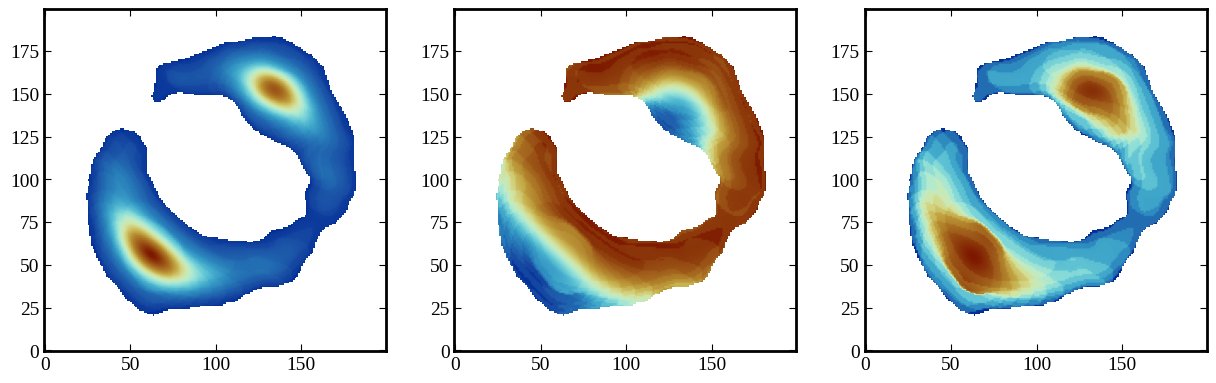

In [45]:
mom0 = fits.getdata("./sim_imaging/casa_dirty.mom0.fits")
mom1 = fits.getdata("./sim_imaging/casa_dirty.mom1.fits")
mom2 = fits.getdata("./sim_imaging/casa_dirty.mom2.fits")

fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(mom0, origin='lower', cmap=cm.roma_r)
ax[1].imshow(mom1, origin='lower', cmap=cm.roma_r)
ax[2].imshow(mom2, origin='lower', cmap=cm.roma_r)
plt.show()

In [46]:
# source model cubeのmoments mapも作ってみる
os.system("rm -r ./sim_imaging/sim_imaging.alma.cycle7.5.skymodel.mom*")
for m in [0,1,2]:
    immoments(
        imagename="./sim_imaging/sim_imaging.alma.cycle7.5.skymodel",
        moments=[m],
        axis = 'spectral',
        outfile=f"./sim_imaging/sim_imaging.alma.cycle7.5.skymodel.mom{m}",
        # chans="0~11",
        # includepix=[3*rms, 1000*rms],
    )
    exportfits(
        imagename=f"./sim_imaging/sim_imaging.alma.cycle7.5.skymodel.mom{m}", 
        fitsimage=f"./sim_imaging/sim_imaging.alma.cycle7.5.skymodel.mom{m}.fits", 
        dropdeg=True, overwrite=True
    )

# mock_source.fitsからも同様に
os.system("rm -r ./mock_source_cube.mom*")
for m in [0,1,2]:
    immoments(
        imagename="./mock_source_cube.fits",
        moments=[m],
        axis = 'spectral',
        outfile=f"./mock_source_cube.mom{m}",
        # chans="0~11",
        # includepix=[3*rms, 1000*rms],
    )
    exportfits(
        imagename=f"./mock_source_cube.mom{m}", 
        fitsimage=f"./mock_source_cube.mom{m}.fits", 
        dropdeg=True, overwrite=True
    )

rm: cannot remove './sim_imaging/sim_imaging.alma.cycle7.5.skymodel.mom*': No such file or directory


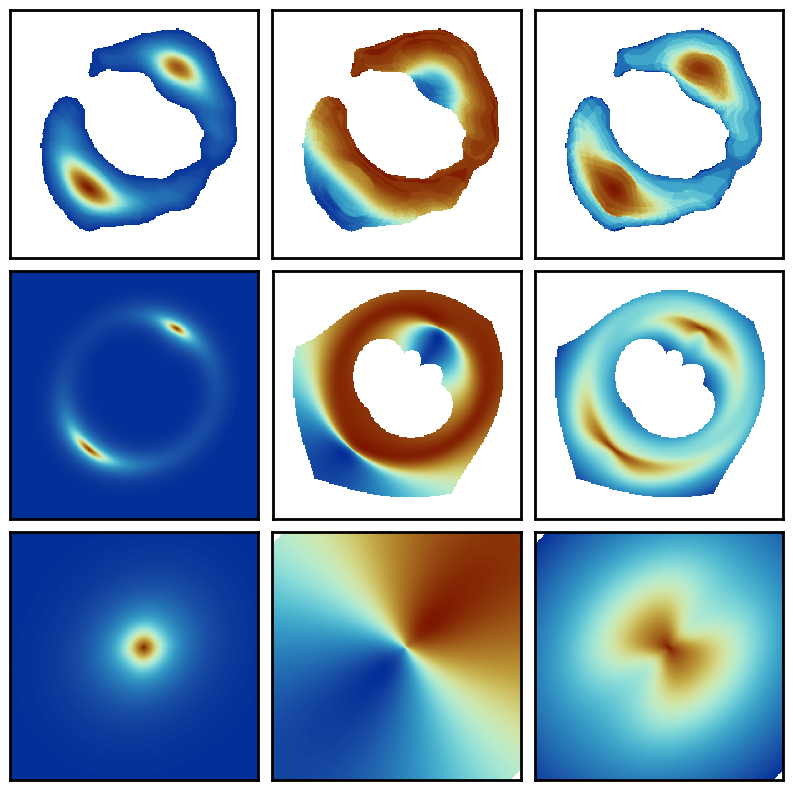

In [47]:
# source model imageと moments mapの比較

fig, ax = plt.subplots(3, 3, figsize=(10,10))
fig.subplots_adjust(wspace=0.05, hspace=0.05)
ax[0,0].imshow(mom0, origin='lower', cmap=cm.roma_r)
ax[0,1].imshow(mom1, origin='lower', cmap=cm.roma_r)
ax[0,2].imshow(mom2, origin='lower', cmap=cm.roma_r)
ax[1,0].imshow(fits.getdata("./sim_imaging/sim_imaging.alma.cycle7.5.skymodel.mom0.fits"), origin='lower', cmap=cm.roma_r)
ax[1,1].imshow(fits.getdata("./sim_imaging/sim_imaging.alma.cycle7.5.skymodel.mom1.fits"), origin='lower', cmap=cm.roma_r)
ax[1,2].imshow(fits.getdata("./sim_imaging/sim_imaging.alma.cycle7.5.skymodel.mom2.fits"), origin='lower', cmap=cm.roma_r)
ax[2,0].imshow(fits.getdata("./mock_source_cube.mom0.fits"), origin='lower', cmap=cm.roma_r)
ax[2,1].imshow(fits.getdata("./mock_source_cube.mom1.fits"), origin='lower', cmap=cm.roma_r)
ax[2,2].imshow(fits.getdata("./mock_source_cube.mom2.fits"), origin='lower', cmap=cm.roma_r)

# tick消す
for a in ax.flat:
    a.set_xticks([])
    a.set_yticks([])
plt.show()

In [48]:
# peak velocity of the simulated source (from the dirty image)

peak_vel_sim_r = np.nanmax(mom1)
peak_vel_sim_b = np.nanmin(mom1)
print(f"Peak velocity (red side): {peak_vel_sim_r:.2f} km/s")
print(f"Peak velocity (blue side): {peak_vel_sim_b:.2f} km/s")

# peak velocity of the lensed source (before simulation, from the model cube)
peak_vel_model_r = np.nanmax(fits.getdata("./sim_imaging/sim_imaging.alma.cycle7.5.skymodel.mom1.fits"))
peak_vel_model_b = np.nanmin(fits.getdata("./sim_imaging/sim_imaging.alma.cycle7.5.skymodel.mom1.fits"))
print(f"Peak velocity of the model (red side): {peak_vel_model_r:.2f} km/s")
print(f"Peak velocity of the model (blue side): {peak_vel_model_b:.2f} km/s")

Peak velocity (red side): 250.00 km/s
Peak velocity (blue side): -200.00 km/s
Peak velocity of the model (red side): 248.90 km/s
Peak velocity of the model (blue side): -205.69 km/s


In [49]:
np.cos(np.deg2rad(31.97))

np.float64(0.8483254449730686)

In [50]:
(peak_vel_model_b - peak_vel_model_r) / 2 / np.cos(np.deg2rad(31.97))

np.float64(-267.93655093776425)